# 1.3 — Toolbox shakedown

02805 Social Graphs and Interactions.

Goal: confirm Python + JupyterLab + NetworkX are working, then load Zachary's Karate Club,
draw it, and report basic structure (nodes, edges, top-5 degrees).

## 0. Environment check

In [1]:
import sys
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt

print("Python    ", sys.version.split()[0])
print("NetworkX  ", nx.__version__)
print("Matplotlib", matplotlib.__version__)

Python     3.14.6
NetworkX   3.6.1
Matplotlib 3.11.1


## 1. Load the network

The Karate Club is bundled with NetworkX, so no download is needed. It records friendships
between 34 members of a university karate club that split into two factions after a dispute
between the instructor (node 0) and the president (node 33).

In [2]:
G = nx.karate_club_graph()
G

## 2. Draw it

Only the two people the split was about are labelled. Everything else is carried by
colour (which faction) and circle size (how many friends).

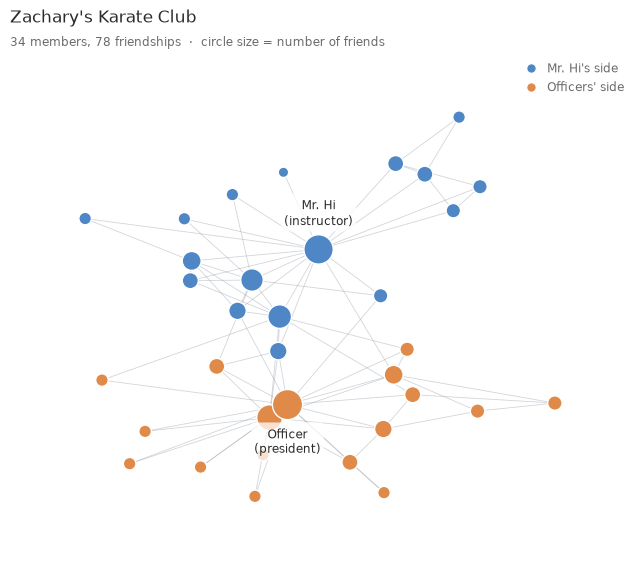

In [3]:
from matplotlib.lines import Line2D

BLUE, ORANGE = "#4F86C6", "#E08A4A"      # validated for colour-blind separation
INK, MUTED, EDGE = "#2B2B2B", "#6B6B6B", "#9AA3AD"

pos = nx.spring_layout(G, seed=42, k=0.30, iterations=200)

colors = [BLUE if G.nodes[n]["club"] == "Mr. Hi" else ORANGE for n in G.nodes()]
sizes = [30 + 26 * G.degree(n) for n in G.nodes()]

fig, ax = plt.subplots(figsize=(8, 6.5))

nx.draw_networkx_edges(G, pos, edge_color=EDGE, alpha=0.45, width=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=sizes,
                       edgecolors="white", linewidths=1.0, ax=ax)

# label only the instructor and the president, each pushed away from its cluster
for node, name, dy, va in [(0, "Mr. Hi\n(instructor)", 15, "bottom"),
                           (33, "Officer\n(president)", -15, "top")]:
    x, y = pos[node]
    ax.annotate(name, (x, y), xytext=(0, dy), textcoords="offset points",
                ha="center", va=va, fontsize=8.5, color=INK, linespacing=1.35,
                bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))

handles = [Line2D([], [], marker="o", linestyle="", markersize=7,
                  markerfacecolor=c, markeredgecolor="white", label=l)
           for c, l in [(BLUE, "Mr. Hi's side"), (ORANGE, "Officers' side")]]
ax.legend(handles=handles, loc="upper right", frameon=False,
          fontsize=8.5, labelcolor=MUTED, handletextpad=0.4, borderpad=0)

ax.text(0, 1.06, "Zachary's Karate Club", transform=ax.transAxes,
        fontsize=12, color=INK, va="bottom")
ax.text(0, 1.015, "34 members, 78 friendships  ·  circle size = number of friends",
        transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")

ax.margins(0.10)
ax.axis("off")
fig.savefig("figures/karate_club.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. The numbers

In [4]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()

print(f"Nodes: {n_nodes}")
print(f"Edges: {n_edges}")
print(f"Average degree: {2 * n_edges / n_nodes:.2f}")
print(f"Density: {nx.density(G):.3f}")

Nodes: 34
Edges: 78
Average degree: 4.59
Density: 0.139


### Five highest-degree nodes

In [5]:
top5 = sorted(G.degree(), key=lambda kv: kv[1], reverse=True)[:5]

print(f"{'node':>5}  {'degree':>6}  faction")
for node, deg in top5:
    print(f"{node:>5}  {deg:>6}  {G.nodes[node]['club']}")

 node  degree  faction
   33      17  Officer
    0      16  Mr. Hi
   32      12  Officer
    2      10  Mr. Hi
    1       9  Mr. Hi


Nodes 33 and 0 sit at the top, which is what the story predicts: the president and the
instructor. Their pull on the rest of the club is what makes the network split cleanly in two.

### Degree distribution

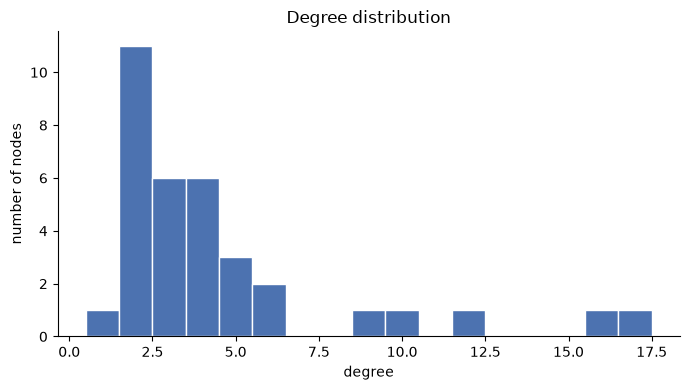

In [6]:
degrees = [d for _, d in G.degree()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(degrees, bins=range(1, max(degrees) + 2), align="left",
        color="#4C72B0", edgecolor="white")
ax.set_xlabel("degree")
ax.set_ylabel("number of nodes")
ax.set_title("Degree distribution")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Views with no overlapping nodes

A spring layout optimises for a tidy-looking energy minimum. Non-overlap is not one of
its constraints, so on a graph this dense some circles will always collide. Two views
put every node in a slot of its own by construction.

### 4a. Adjacency matrix

Row *i*, column *j* is filled when *i* and *j* are friends. Nothing can overlap, because
every possible friendship owns exactly one cell.

Members are ordered by faction, so the split shows up as two solid blocks on the diagonal.
Dark cells are the friendships that cross the divide.

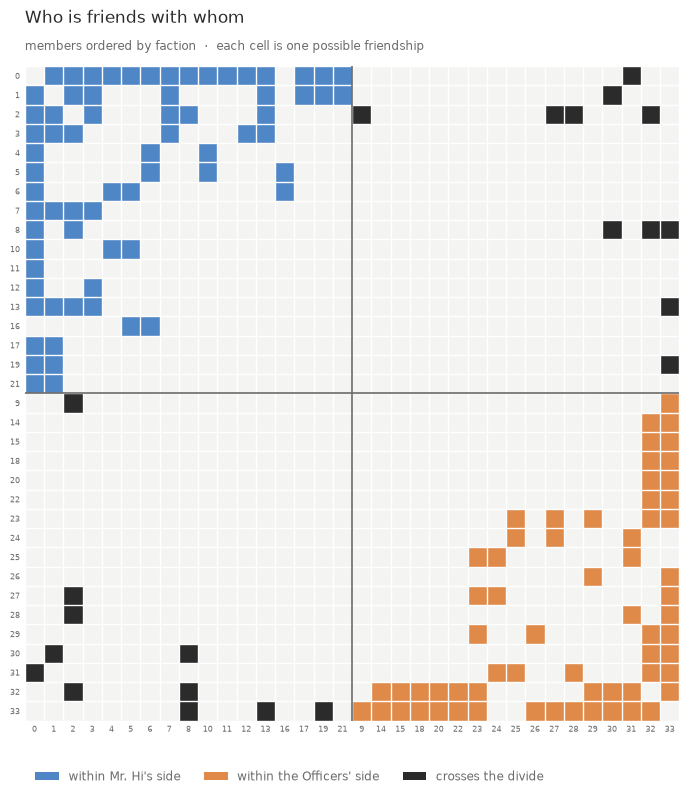

In [7]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

# order members by faction so the two communities sit in adjacent blocks
hi = [n for n in G.nodes() if G.nodes[n]["club"] == "Mr. Hi"]
off = [n for n in G.nodes() if G.nodes[n]["club"] != "Mr. Hi"]
order = hi + off
split = len(hi)

# NOTE: Zachary's data carries edge weights, so binarise before counting
A = (nx.to_numpy_array(G, nodelist=order) > 0).astype(int)

# 0 = no edge, 1 = within Mr. Hi, 2 = within Officers, 3 = crosses the divide
side = np.array([0] * len(hi) + [1] * len(off))
same = side[:, None] == side[None, :]
cat = np.zeros_like(A, dtype=int)
cat[(A == 1) & same & (side[:, None] == 0)] = 1
cat[(A == 1) & same & (side[:, None] == 1)] = 2
cat[(A == 1) & ~same] = 3

cmap = ListedColormap(["#F4F4F2", BLUE, ORANGE, INK])

fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.imshow(cat, cmap=cmap, vmin=0, vmax=3, interpolation="nearest")

# one thin gridline per member
ax.set_xticks(np.arange(-0.5, len(order), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(order), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="minor", length=0)

# heavier rule where the club splits
for v in (split - 0.5,):
    ax.axhline(v, color=MUTED, linewidth=1.2)
    ax.axvline(v, color=MUTED, linewidth=1.2)

ax.set_xticks(range(len(order)))
ax.set_yticks(range(len(order)))
ax.set_xticklabels(order, fontsize=6, color=MUTED)
ax.set_yticklabels(order, fontsize=6, color=MUTED)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

ax.legend(handles=[Patch(facecolor=BLUE, label="within Mr. Hi's side"),
                   Patch(facecolor=ORANGE, label="within the Officers' side"),
                   Patch(facecolor=INK, label="crosses the divide")],
          loc="upper left", bbox_to_anchor=(0, -0.06), ncol=3,
          frameon=False, fontsize=8.5, labelcolor=MUTED)

ax.text(0, 1.06, "Who is friends with whom", transform=ax.transAxes,
        fontsize=12, color=INK, va="bottom")
ax.text(0, 1.02, "members ordered by faction  ·  each cell is one possible friendship",
        transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")

fig.savefig("figures/karate_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

Counting is now exact rather than eyeballed. The matrix is symmetric because friendship
goes both ways, so every edge appears twice.

In [8]:
filled = int(A.sum())
cross = int((cat == 3).sum() // 2)

print(f"Filled cells:        {filled}")
print(f"Edges (filled / 2):  {filled // 2}")
print(f"NetworkX agrees:     {G.number_of_edges()}")
print()
print(f"Friendships crossing the divide: {cross} out of {G.number_of_edges()}")
print()
print("Degree = the number of filled cells in a member's row:")
for node in [0, 33, 9]:
    row = int(A[order.index(node)].sum())
    print(f"  node {node:>2}: {row} filled cells, G.degree = {G.degree(node)}")

Filled cells:        156
Edges (filled / 2):  78
NetworkX agrees:     78

Friendships crossing the divide: 11 out of 78

Degree = the number of filled cells in a member's row:
  node  0: 16 filled cells, G.degree = 16
  node 33: 17 filled cells, G.degree = 17
  node  9: 2 filled cells, G.degree = 2


### 4b. Circular layout

If you want to keep the node-link picture, put every member on a circle. The spacing is
fixed, so nodes cannot collide, and each member's degree is countable by following the
lines leaving their dot.

Edges are drawn as gentle arcs. Straight chords would pile up along the centre; bending
them lets you trace an individual friendship.

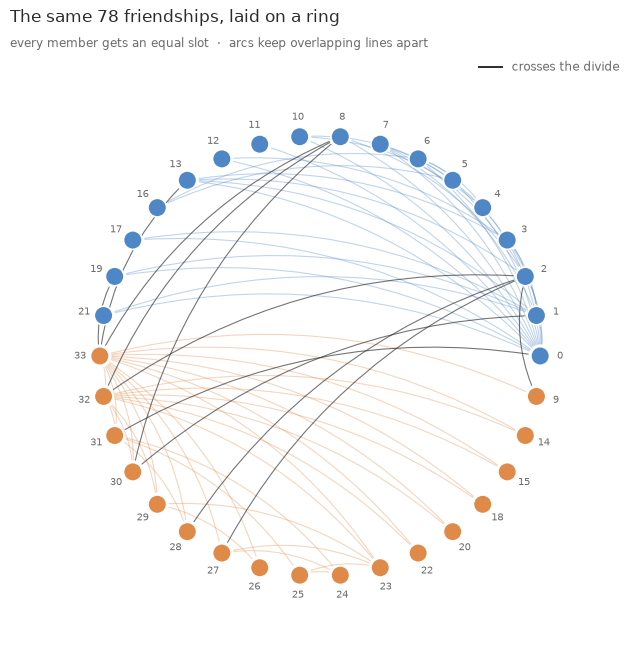

In [9]:
order_circ = hi + off[::-1]          # keep each faction contiguous around the ring
pos_c = nx.circular_layout(order_circ)

fig, ax = plt.subplots(figsize=(8, 8))

within_hi = [(u, v) for u, v in G.edges()
             if G.nodes[u]["club"] == G.nodes[v]["club"] == "Mr. Hi"]
within_off = [(u, v) for u, v in G.edges()
              if G.nodes[u]["club"] == G.nodes[v]["club"] == "Officer"]
crossing = [(u, v) for u, v in G.edges() if G.nodes[u]["club"] != G.nodes[v]["club"]]

# bridges drawn last so they sit on top
for elist, c, a in [(within_hi, BLUE, 0.35), (within_off, ORANGE, 0.35),
                    (crossing, INK, 0.65)]:
    nx.draw_networkx_edges(G, pos_c, edgelist=elist, edge_color=c, alpha=a, width=0.8,
                           connectionstyle="arc3,rad=0.18", arrows=True,
                           arrowstyle="-", ax=ax)

nx.draw_networkx_nodes(G, pos_c, nodelist=order_circ,
                       node_color=[BLUE if G.nodes[n]["club"] == "Mr. Hi" else ORANGE
                                   for n in order_circ],
                       node_size=180, edgecolors="white", linewidths=1.2, ax=ax)

# push each id just outside its dot
for n, (x, y) in pos_c.items():
    ax.annotate(str(n), (x * 1.09, y * 1.09), ha="center", va="center",
                fontsize=7.5, color=MUTED)

ax.legend(handles=[Line2D([], [], color=INK, lw=1.4, label="crosses the divide")],
          loc="upper right", frameon=False, fontsize=8.5, labelcolor=MUTED)

ax.text(0, 1.04, "The same 78 friendships, laid on a ring", transform=ax.transAxes,
        fontsize=12, color=INK, va="bottom")
ax.text(0, 1.0, "every member gets an equal slot  ·  arcs keep overlapping lines apart",
        transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")

ax.set_aspect("equal")
ax.margins(0.14)
ax.axis("off")
fig.savefig("figures/karate_circular.png", dpi=200, bbox_inches="tight")
plt.show()

### 4c. Kamada-Kawai, for comparison

Neither guarantee comes free. If you want to keep an organic-looking drawing, Kamada-Kawai
is the middle option: it places nodes so that drawn distance tracks shortest-path distance
in the graph, which spreads things more evenly than a spring layout. Overlap gets rarer.
It is still not impossible.

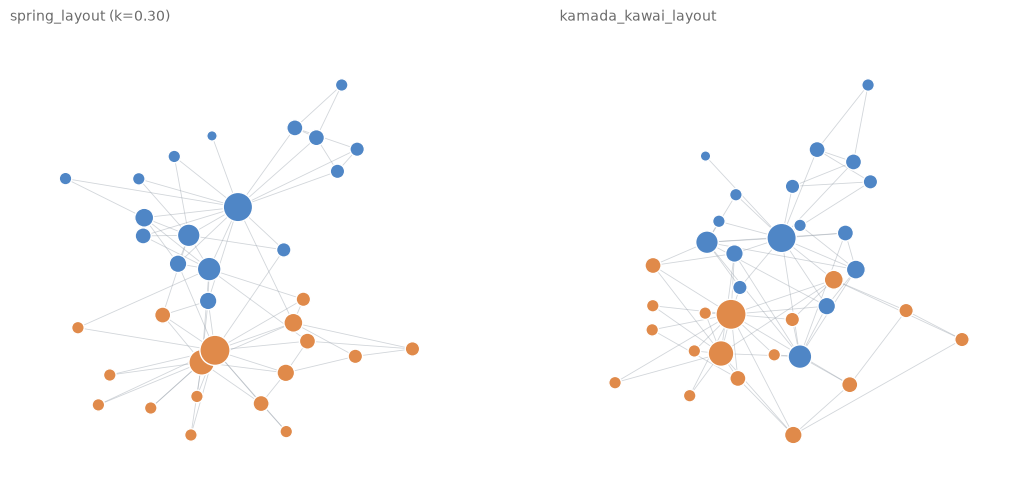

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

layouts = [("spring_layout (k=0.30)", nx.spring_layout(G, seed=42, k=0.30, iterations=200)),
           ("kamada_kawai_layout", nx.kamada_kawai_layout(G))]

for ax, (name, p) in zip(axes, layouts):
    nx.draw_networkx_edges(G, p, edge_color=EDGE, alpha=0.45, width=0.6, ax=ax)
    nx.draw_networkx_nodes(G, p,
                           node_color=[BLUE if G.nodes[n]["club"] == "Mr. Hi" else ORANGE
                                       for n in G.nodes()],
                           node_size=[30 + 26 * G.degree(n) for n in G.nodes()],
                           edgecolors="white", linewidths=1.0, ax=ax)
    ax.set_title(name, fontsize=10, color=MUTED, loc="left")
    ax.margins(0.10)
    ax.axis("off")

fig.savefig("figures/karate_layout_compare.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
# how close does each layout come to keeping nodes apart?
from itertools import combinations

def closest_pair_gap(p):
    """Smallest centre-to-centre distance, as a fraction of the drawing's width."""
    span = max(max(abs(a[0] - b[0]), abs(a[1] - b[1]))
               for a, b in combinations(p.values(), 2))
    return min(float(np.hypot(*(p[u] - p[v]))) for u, v in combinations(p, 2)) / span

for name, p in layouts:
    print(f"{name:<24} closest pair sits {closest_pair_gap(p):.3f} of the width apart")

spring_layout (k=0.30)   closest pair sits 0.039 of the width apart
kamada_kawai_layout      closest pair sits 0.056 of the width apart


# 5. Building the adjacency-matrix explorable by hand

Reading a matrix off a graph is one direction. This section goes the other way: write the
matrix first, by hand, and make NetworkX produce the drawing from it. Six nodes, small
enough to check every claim by eye.

The convention throughout: **`A[i, j] = 1` means an arc runs from `i` to `j`.** Row `i`
is everything leaving node `i`. Column `j` is everything arriving at node `j`.

## 5a. A directed graph, typed in as a matrix

In [12]:
import numpy as np

# hand-written 6x6 adjacency matrix. A[i, j] = 1 means i -> j
A = np.array([
    [0, 1, 1, 0, 0, 0],   # 0 -> 1, 2
    [0, 0, 1, 0, 0, 0],   # 1 -> 2
    [0, 1, 0, 1, 0, 0],   # 2 -> 1, 3   <- 1 and 2 point at each other
    [1, 0, 0, 0, 1, 0],   # 3 -> 0, 4
    [0, 0, 0, 0, 0, 1],   # 4 -> 5
    [0, 0, 0, 1, 0, 0],   # 5 -> 3
])

D = nx.from_numpy_array(A, create_using=nx.DiGraph)

print(D)
print("arcs:", sorted(D.edges()))
print("matrix total:", int(A.sum()))

DiGraph with 6 nodes and 9 edges
arcs: [(0, 1), (0, 2), (1, 2), (2, 1), (2, 3), (3, 0), (3, 4), (4, 5), (5, 3)]
matrix total: 9


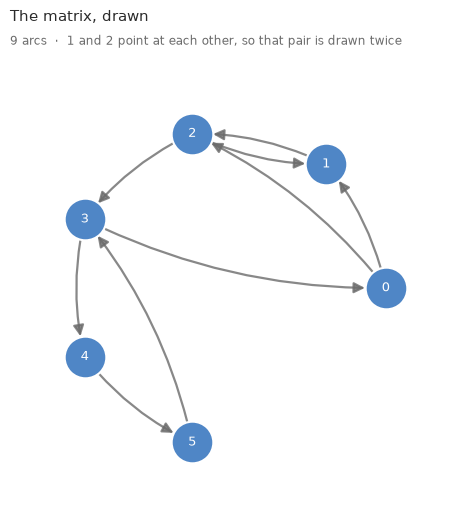

In [13]:
NODE = 900
POS = nx.circular_layout(list(range(7)))     # shared so a node keeps its spot in every figure

def draw(H, ax, heading, sub, color=BLUE):
    """Draw H with arrowheads only if it is directed, line width tracking weight."""
    pos = {n: POS[n] for n in H.nodes()}
    edges = list(H.edges())
    widths = [0.9 + 0.7 * H[u][v].get("weight", 1) for u, v in edges]
    nx.draw_networkx_edges(H, pos, edgelist=edges, ax=ax, width=widths,
                           edge_color=MUTED, alpha=0.8, node_size=NODE,
                           arrows=True, arrowsize=16,
                           arrowstyle="-|>" if H.is_directed() else "-",
                           connectionstyle="arc3,rad=0.12")
    nx.draw_networkx_nodes(H, pos, ax=ax, node_color=color, node_size=NODE,
                           edgecolors="white", linewidths=1.5)
    nx.draw_networkx_labels(H, pos, ax=ax, font_size=9, font_color="white")
    ax.text(0, 1.07, heading, transform=ax.transAxes, fontsize=11, color=INK, va="bottom")
    ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=8.5, color=MUTED, va="bottom")
    ax.set_aspect("equal")
    ax.margins(0.18)
    ax.axis("off")

fig, ax = plt.subplots(figsize=(6.5, 6))
draw(D, ax, "The matrix, drawn", "9 arcs  ·  1 and 2 point at each other, so that pair is drawn twice")
fig.savefig("figures/explorable_directed.png", dpi=200, bbox_inches="tight")
plt.show()

### Do the sums agree with NetworkX?

Row sum should be out-degree, column sum should be in-degree. Asserting it rather than
eyeballing it, so the notebook fails loudly if the convention ever flips.

In [14]:
row = A.sum(axis=1)      # arcs leaving i
col = A.sum(axis=0)      # arcs arriving at j

print(f"{'node':>5}{'row sum':>10}{'out_degree':>12}{'col sum':>10}{'in_degree':>11}")
for n in D.nodes():
    print(f"{n:>5}{row[n]:>10}{D.out_degree(n):>12}{col[n]:>10}{D.in_degree(n):>11}")

assert list(row) == [D.out_degree(n) for n in D.nodes()], "row sums are not out-degree"
assert list(col) == [D.in_degree(n) for n in D.nodes()], "column sums are not in-degree"
assert row.sum() == col.sum() == D.number_of_edges()

print()
print("Row sums match out-degree. Column sums match in-degree. Both total", int(row.sum()), "arcs.")

 node   row sum  out_degree   col sum  in_degree
    0         2           2         1          1
    1         1           1         2          2
    2         2           2         2          2
    3         2           2         2          2
    4         1           1         1          1
    5         1           1         1          1

Row sums match out-degree. Column sums match in-degree. Both total 9 arcs.


## 5b. Symmetrize, and watch the arrowheads go

`A + A.T` records "a link exists in either direction". Where a pair already pointed both
ways, the sum lands on **2**, which is why the clip is needed: an adjacency matrix for a
simple undirected graph holds 0 or 1, nothing else.

In [15]:
raw = A + A.T
mutual = [(i, j) for i in range(len(raw)) for j in range(i + 1, len(raw)) if raw[i, j] == 2]

print("A + A.T:")
print(raw)
print()
print("cells that landed on 2 (pairs that already pointed both ways):", mutual)

S = np.clip(raw, 0, 1)
U = nx.from_numpy_array(S)          # no create_using -> undirected Graph

print()
print("symmetric?", bool((S == S.T).all()))
print(U)
print("9 arcs became", U.number_of_edges(), "edges: the mutual pair collapsed into one.")

A + A.T:
[[0 1 1 1 0 0]
 [1 0 2 0 0 0]
 [1 2 0 1 0 0]
 [1 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]

cells that landed on 2 (pairs that already pointed both ways): [(1, 2)]

symmetric? True
Graph with 6 nodes and 8 edges
9 arcs became 8 edges: the mutual pair collapsed into one.


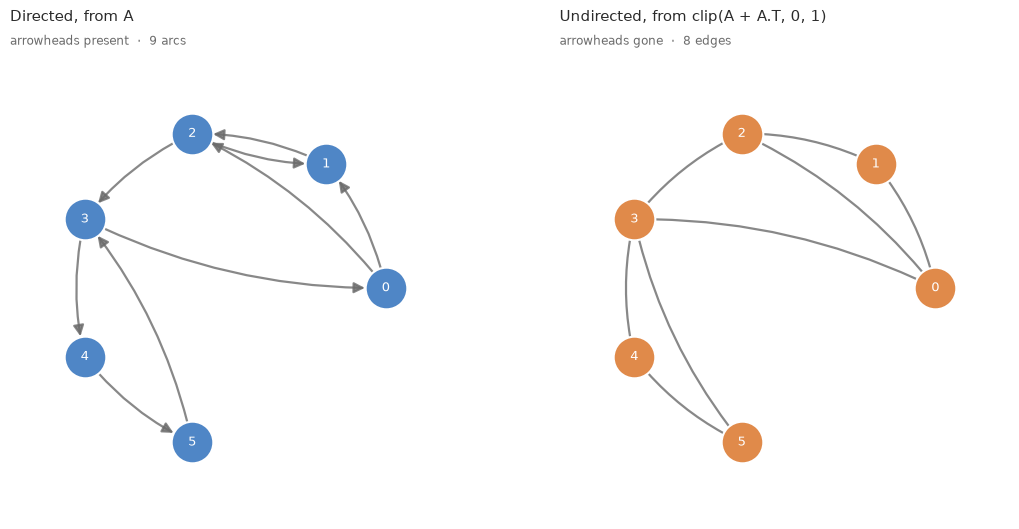

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw(D, axes[0], "Directed, from A", "arrowheads present  ·  9 arcs")
draw(U, axes[1], "Undirected, from clip(A + A.T, 0, 1)", "arrowheads gone  ·  8 edges", color=ORANGE)
fig.savefig("figures/explorable_symmetrize.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
# in an undirected graph there is only one degree, and it is the row sum again
assert list(S.sum(axis=1)) == [U.degree(n) for n in U.nodes()]
print("Undirected row sums match degree:", S.sum(axis=1).tolist())

Undirected row sums match degree: [3, 2, 3, 4, 2, 2]


## 5c. Plant a weight, an isolate and a self-loop

Three things the explorable says the matrix can hold, each with a signature in the drawing:

| planted in the matrix | where it shows up |
|---|---|
| a value above 1 off the diagonal | a weighted edge, drawn thicker |
| an all-zero row **and** column | an isolate: a node with no lines at all |
| a value on the diagonal `B[i, i]` | a self-loop: an edge from a node back to itself |

In [18]:
n = 7
B = np.zeros((n, n))
B[:6, :6] = A         # start from the same graph

B[0, 1] = 4.0         # a weight: the arc 0 -> 1 is four times as strong
B[4, 4] = 1.0         # a self-loop on the diagonal
# node 6 is left as an all-zero row and column: an isolate

print(B.astype(int))

P = nx.from_numpy_array(B, create_using=nx.DiGraph)

[[0 4 1 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 1 0 1 0 0 0]
 [1 0 0 0 1 0 0]
 [0 0 0 0 1 1 0]
 [0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0]]


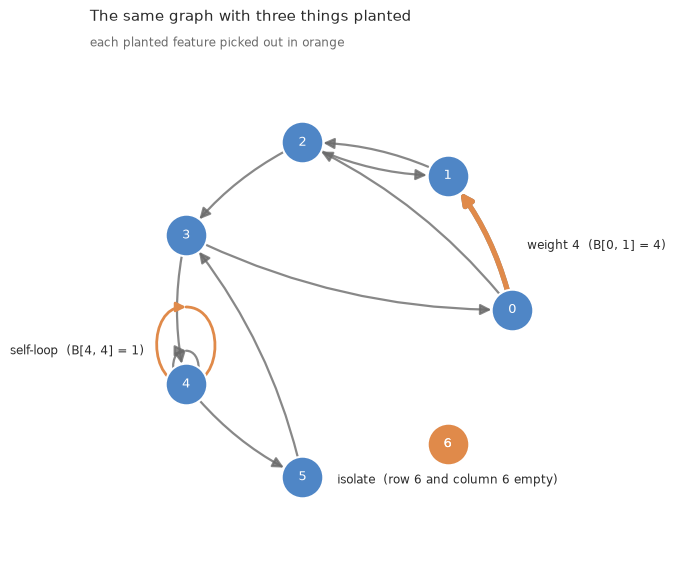

In [19]:
fig, ax = plt.subplots(figsize=(7, 6.5))
draw(P, ax, "The same graph with three things planted",
     "each planted feature picked out in orange")

pos = {n: POS[n] for n in P.nodes()}

# repaint the three planted features so they read at a glance
nx.draw_networkx_edges(P, pos, edgelist=[(0, 1)], ax=ax, edge_color=ORANGE,
                       width=0.9 + 0.7 * 4, arrows=True, arrowstyle="-|>",
                       arrowsize=16, node_size=NODE, connectionstyle="arc3,rad=0.12")
nx.draw_networkx_edges(P, pos, edgelist=list(nx.selfloop_edges(P)), ax=ax,
                       edge_color=ORANGE, width=2.0, arrows=True, arrowstyle="-|>",
                       arrowsize=14, node_size=NODE)
nx.draw_networkx_nodes(P, pos, nodelist=[6], ax=ax, node_color=ORANGE,
                       node_size=NODE, edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(P, pos, labels={6: "6"}, ax=ax, font_size=9, font_color="white")

for xy, text, off, ha in [((POS[0] + POS[1]) / 2, "weight 4  (B[0, 1] = 4)", (34, -2), "left"),
                          (POS[4], "self-loop  (B[4, 4] = 1)", (-30, 24), "right"),
                          (POS[6], "isolate  (row 6 and column 6 empty)", (0, -26), "center")]:
    ax.annotate(text, xy, xytext=off, textcoords="offset points",
                fontsize=8.5, color=INK, ha=ha, va="center")

fig.savefig("figures/explorable_planted.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
print("WEIGHT")
print("  B[0, 1] =", B[0, 1], "-> edge attribute:", P[0][1])
assert P[0][1]["weight"] == 4.0

print()
print("ISOLATE")
print("  row 6 sum =", int(B[6].sum()), " column 6 sum =", int(B[:, 6].sum()))
print("  nx.isolates ->", list(nx.isolates(P)))
assert list(nx.isolates(P)) == [6]

print()
print("SELF-LOOP")
print("  diagonal:", B.diagonal().astype(int))
print("  nx.selfloop_edges ->", list(nx.selfloop_edges(P)))
assert list(nx.selfloop_edges(P)) == [(4, 4)]

print()
print("All three landed where the explorable says they should.")

WEIGHT
  B[0, 1] = 4.0 -> edge attribute: {'weight': 4.0}

ISOLATE
  row 6 sum = 0  column 6 sum = 0
  nx.isolates -> [6]

SELF-LOOP
  diagonal: [0 0 0 0 1 0 0]
  nx.selfloop_edges -> [(4, 4)]

All three landed where the explorable says they should.


### One catch worth carrying forward

Row sum equals out-degree **only while the matrix is binary**. Once a weight is planted,
the row sum becomes the *weighted* out-degree, and the two answers separate. This is the
same trap that inflated the karate-club edge count in section 4a, where NetworkX handed
back Zachary's interaction strengths instead of ones and zeros.

In [21]:
print(f"{'node':>5}{'row sum':>10}{'out_degree':>12}{'weighted':>11}")
for i in P.nodes():
    print(f"{i:>5}{B[i].sum():>10.1f}{P.out_degree(i):>12}{P.out_degree(i, weight='weight'):>11.1f}")

print()
print("Node 0: row sum", B[0].sum(), "but out_degree", P.out_degree(0),
      "- it still has just two arcs, one of them heavy.")
print("Binarise first and the identity comes back:")
assert list((B > 0).sum(axis=1)) == [P.out_degree(i) for i in P.nodes()]
print("  (B > 0).sum(axis=1) ==", (B > 0).sum(axis=1).tolist())

 node   row sum  out_degree   weighted
    0       5.0           2        5.0
    1       1.0           1        1.0
    2       2.0           2        2.0
    3       2.0           2        2.0
    4       2.0           2        2.0
    5       1.0           1        1.0
    6       0.0           0        0.0

Node 0: row sum 5.0 but out_degree 2 - it still has just two arcs, one of them heavy.
Binarise first and the identity comes back:
  (B > 0).sum(axis=1) == [2, 1, 2, 2, 2, 1, 0]
